In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
# Run this first every time

In [ ]:
# Upload the CSV file to Colab first (Files icon → Upload)
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
print("Shape:", df.shape)
df.head()

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# Check nulls
print("Null values:\n", df.isnull().sum())

# Check duplicates
print("\nDuplicates:", df.duplicated().sum())
df = df.drop_duplicates()

# Fix date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract Year and Month
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.to_period('M')

print("\nCleaning done! Shape:", df.shape)

Null values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicates: 0

Cleaning done! Shape: (9994, 23)


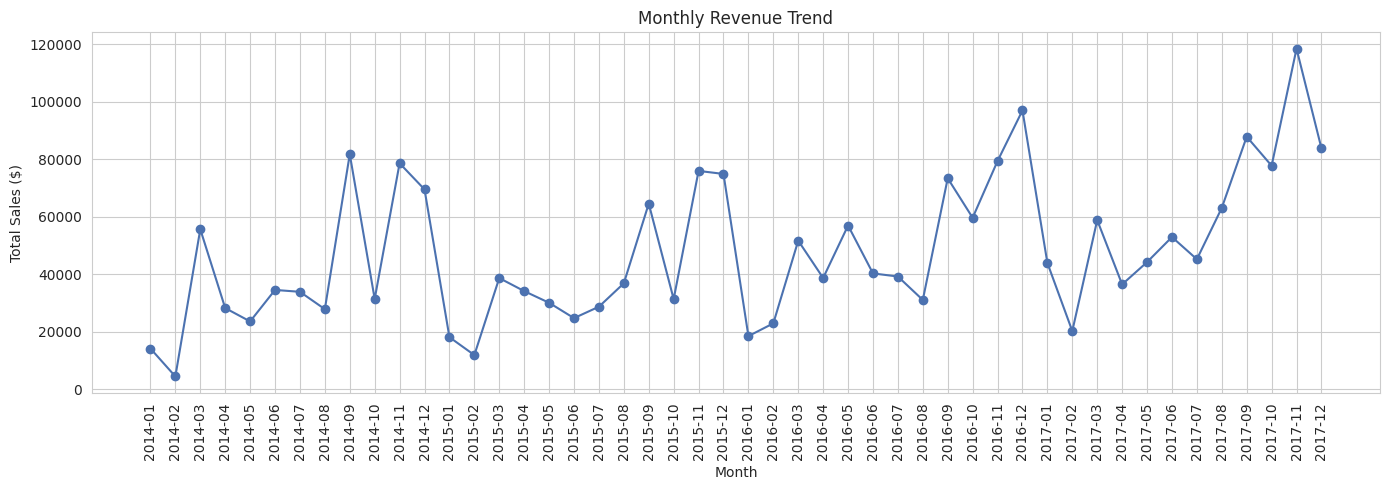

In [ ]:
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

plt.figure(figsize=(14,5))
plt.plot(monthly_sales['Month'], monthly_sales['Sales'], marker='o', color='#4C72B0')
plt.xticks(rotation=90)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

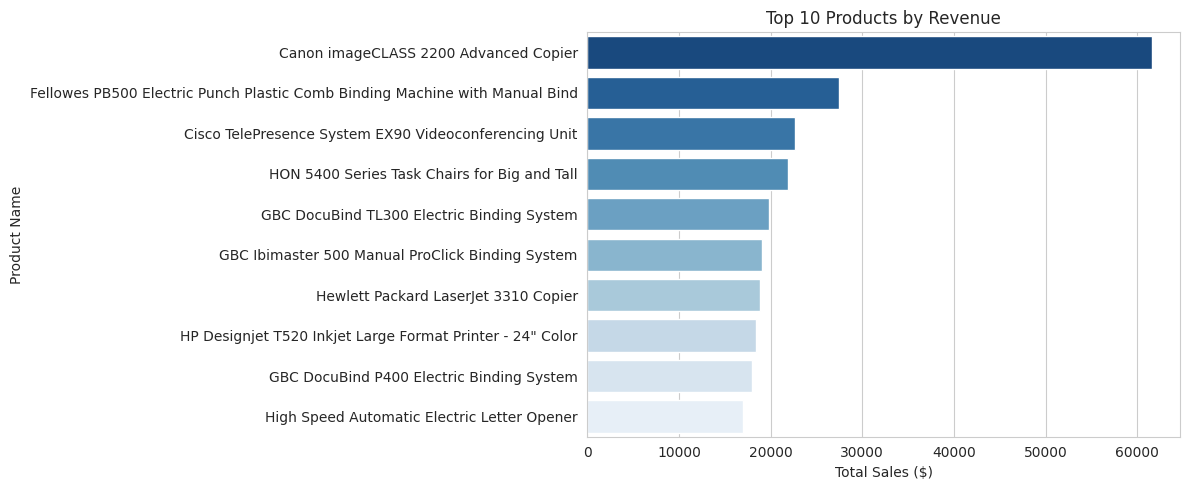

In [ ]:
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12,5))
sns.barplot(data=top_products, x='Sales', y='Product Name', palette='Blues_r')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.show()

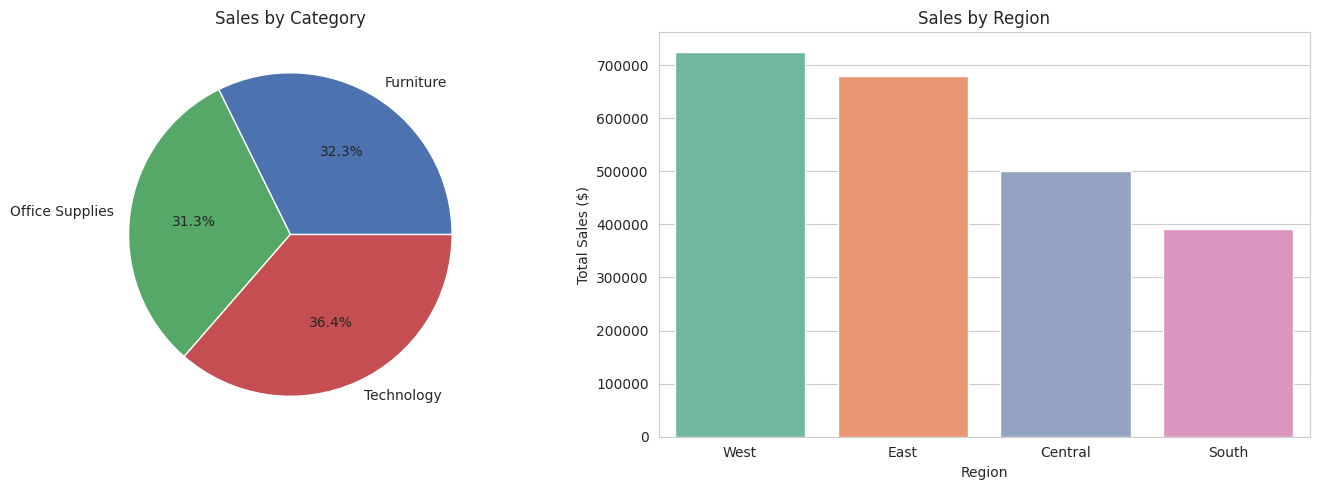

In [ ]:
# Category breakdown
cat_sales = df.groupby('Category')['Sales'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(cat_sales['Sales'], labels=cat_sales['Category'],
           autopct='%1.1f%%', colors=['#4C72B0','#55A868','#C44E52'])
axes[0].set_title('Sales by Category')

# Region breakdown
reg_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=reg_sales.index, y=reg_sales.values, palette='Set2', ax=axes[1])
axes[1].set_title('Sales by Region')
axes[1].set_ylabel('Total Sales ($)')

plt.tight_layout()
plt.show()

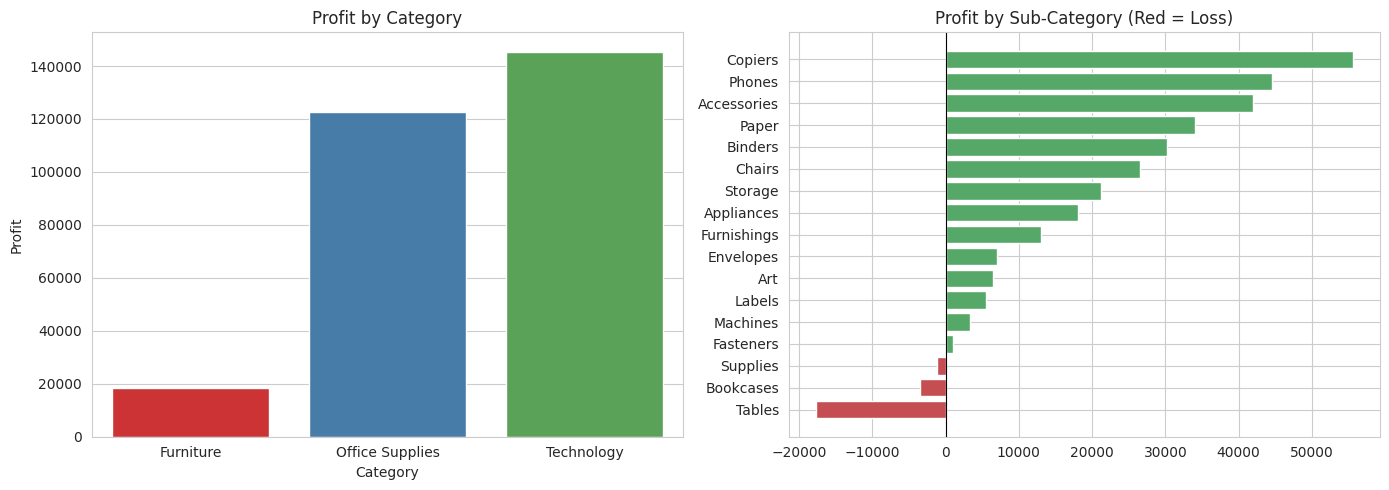

In [ ]:
profit_cat = df.groupby('Category')['Profit'].sum().reset_index()
profit_sub = df.groupby('Sub-Category')['Profit'].sum().sort_values().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=profit_cat, x='Category', y='Profit', palette='Set1', ax=axes[0])
axes[0].set_title('Profit by Category')

colors = ['#C44E52' if x < 0 else '#55A868' for x in profit_sub['Profit']]
axes[1].barh(profit_sub['Sub-Category'], profit_sub['Profit'], color=colors)
axes[1].set_title('Profit by Sub-Category (Red = Loss)')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

In [ ]:
total_sales   = df['Sales'].sum()
total_profit  = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100
top_region    = df.groupby('Region')['Sales'].sum().idxmax()
top_category  = df.groupby('Category')['Sales'].sum().idxmax()
best_year     = df.groupby('Year')['Sales'].sum().idxmax()

print(f"Total Revenue    : ${total_sales:,.2f}")
print(f"Total Profit     : ${total_profit:,.2f}")
print(f"Profit Margin    : {profit_margin:.1f}%")
print(f"Top Region       : {top_region}")
print(f"Top Category     : {top_category}")
print(f"Best Sales Year  : {best_year}")

Total Revenue    : $2,297,200.86
Total Profit     : $286,397.02
Profit Margin    : 12.5%
Top Region       : West
Top Category     : Technology
Best Sales Year  : 2017


In [1]:
print("""
## Key Business Insights

1. REVENUE GROWTH: Sales grew consistently from 2014 to 2017,
   peaking at ~$120K in Nov 2017, showing strong YoY growth.

2. TOP CATEGORY: Technology leads with 36.4% of total sales.
   Canon imageCLASS 2200 Copier is the #1 revenue product (~$60K).

3. REGIONAL PERFORMANCE: West region dominates sales ($700K+),
   followed closely by East. South is the weakest region.

4. PROFIT ALERT: Furniture has NEGATIVE profit despite 32.3% sales share.
   Tables and Bookcases are loss-making sub-categories.

5. RECOMMENDATION: Discontinue or reprice Tables/Bookcases.
   Double down on Technology products in West & East regions.
""")


## Key Business Insights

1. REVENUE GROWTH: Sales grew consistently from 2014 to 2017,
   peaking at ~$120K in Nov 2017, showing strong YoY growth.

2. TOP CATEGORY: Technology leads with 36.4% of total sales.
   Canon imageCLASS 2200 Copier is the #1 revenue product (~$60K).

3. REGIONAL PERFORMANCE: West region dominates sales ($700K+),
   followed closely by East. South is the weakest region.

4. PROFIT ALERT: Furniture has NEGATIVE profit despite 32.3% sales share.
   Tables and Bookcases are loss-making sub-categories.

5. RECOMMENDATION: Discontinue or reprice Tables/Bookcases.
   Double down on Technology products in West & East regions.

